# 1η Σειρά Ασκήσεων

Η παρούσα αναφορά συγγράφεται στα πλαίσια της πρώτης σειράς ασκήσεων.\
Ονοματεπώνυμο: Γιάννης Φίλλης\
ΑΜ: 5380

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score


In [2]:
# loading the test dataset
df_test = pd.read_csv('fashion-mnist_test.csv')

# Loading the training dataset
df_train = pd.read_csv('fashion-mnist_train.csv')

## Κανονικοποίηση Δεδομένων

In [3]:
# Getting the classes
y_train = df_train['label'].values
y_test = df_test['label'].values

# Extracting pixel data of training set and getting the values
pixel_data_train = df_train.drop(columns=['label']).values


# Extracting pixel data of test set and getting the values

pixel_data_test= df_test.drop(columns=['label']).values


# Defining the scaler for testing and training test
scaler_x = MinMaxScaler()


# Scaling the data for the training set and the testing set
data_scaled_train = scaler_x.fit_transform(pixel_data_train)
data_scaled_test = scaler_x.transform(pixel_data_test)

## [A] Διανυσματική Αναπαράσταση

Σε αυτό το σημείο χρησιμοποιούμε την τεχνική max polling στα δεδομένα μας και έπειτα δημιουργούμε την διανυσματική τους μορφή. (διάστασης 49)

In [ ]:
# Reshaping the scaled data 
images_train = torch.tensor(data_scaled_train).view(-1, 1, 28, 28)
images_test = torch.tensor(data_scaled_test).view(-1, 1, 28, 28)
y_train_t = torch.tensor(y_train.reshape(-1,1))
y_test_t = torch.tensor(y_test.reshape(-1,1))
print(images_train.shape)
print(data_scaled_train.shape)
# Defining the max-pooling operation
max_pool = F.max_pool2d

# Apply max pooling to the images
pooled_images_train = max_pool(images_train, kernel_size=4)
pooled_images_test = max_pool(images_test, kernel_size=4)

# Flatten the pooled images into vectors
flattened_vectors_train = pooled_images_train.view(len(images_train), -1)
flattened_vectors_test = pooled_images_test.view(len(images_test), -1)
print(flattened_vectors_train.shape)
print(pooled_images_test.shape)

## KNN Implementation

### KNN N=1

In [28]:
knn_model1 = KNeighborsClassifier(n_neighbors=1)

In [30]:
# performing the fitting
knn_model1.fit(flattened_vectors_train,y_train)


KNeighborsClassifier(n_neighbors=1)

In [31]:
# predicting based on our test dataset
y_pred = knn_model1.predict(flattened_vectors_test)

In [32]:
accuracy = accuracy_score(y_test_t, y_pred)

In [33]:
accuracy

0.7772

In [34]:
precision = precision_score(y_test,y_pred,average=None)
print(precision)

[0.74022066 0.91069676 0.6054358  0.76518219 0.63589744 0.92180617
 0.51326531 0.8465205  0.97210744 0.87225929]


### KNN N=3

In [36]:
knn_model2 = KNeighborsClassifier(n_neighbors=3)

In [37]:
# performing the fitting
knn_model2.fit(flattened_vectors_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
# predicting based on our test dataset
y_pred2 = knn_model2.predict(flattened_vectors_test)

In [39]:
accuracy2 = accuracy_score(y_test_t, y_pred2)

In [40]:
accuracy2

0.792

In [41]:
precision2 = precision_score(y_test,y_pred2,average=None)
print(precision2)

[0.71872227 0.89585342 0.5994898  0.79022403 0.69020021 0.91879867
 0.60550459 0.86180422 0.97390397 0.8678538 ]


### KNN N = 5

In [27]:
knn_model3 = KNeighborsClassifier(n_neighbors=5)

In [28]:
# performing the fitting
knn_model3.fit(flattened_vectors_train,y_train)

KNeighborsClassifier()

In [29]:
# predicting based on our test dataset
y_pred3 = knn_model3.predict(flattened_vectors_test)

In [30]:
accuracy3 = accuracy_score(y_test, y_pred3)

In [31]:
accuracy3

0.8006

In [32]:
precision3 = precision_score(y_test,y_pred3,average=None)
print(precision3)

[0.74585635 0.8960539  0.62264151 0.78456914 0.67979798 0.93984109
 0.63052209 0.8637218  0.97101449 0.87206021]


#### Σχολιασμός επιδόσεων και συμπεριφορών

Αρχικά θα λάβουμε υπόψιν το accuracy, το οποίο όπως παρατηρούμε, καθώς οι γειτονιές αυξάνονται, αυξάνεται και αυτό. Από αυτό συμπεραίνουμε ότι βελτιώνεται η επίδοση και τα λάθη που κάνει στις προβλέψεις είναι συνεχώς λιγότερα.\
Άλλος ένας παράγοντας που θα λάβουμε υπόψιν είναι το precision. Παρακάτω υπάρχει και ένα γράφημα το οποίο αναπαριστά το precision για κάθε κατηγορία, για κάθε μια από τις τρεις περιπτώσεις που αναλύουμε.\
Από εκεί μπορούμε να συμπεράνουμε πως το precision είναι χαμηλότερο για k=1(ειδικά στην κατηγορία 6), ενώ οι άλλες δύο περιπτώσεις(k=3,k=5) έχουν περίπου το ίδιο precision για κάθε κατηγορία με εμφανέστατη διαφορά στις μικρές κατηγορίες(<4) όπου εκεί η περίπτωση για k=3 έχει μεγαλύτερο precision, ενώ για τις μεγαλύτερες κατηγορίες η περίπτωση k=5 έχει μεγαλύτερο precision.

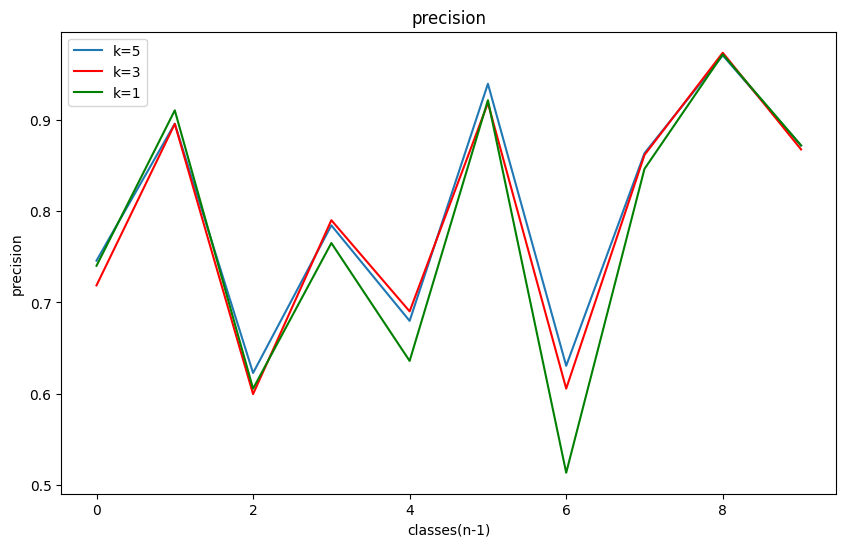

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(precision3,label='k=5')# Plot the line y=x
plt.plot(precision2,color='red',label='k=3')
plt.plot(precision,color='green',label='k=1')
plt.title('precision')
plt.xlabel('classes(n-1)')
plt.ylabel('precision')
plt.legend()
plt.show()

### DECISION TREE

In [6]:
from sklearn import tree

In [7]:
clf = tree.DecisionTreeClassifier(max_depth=10)

In [8]:
clf = clf.fit(flattened_vectors_train, y_train)

In [9]:
y_pred4 = clf.predict(flattened_vectors_test)

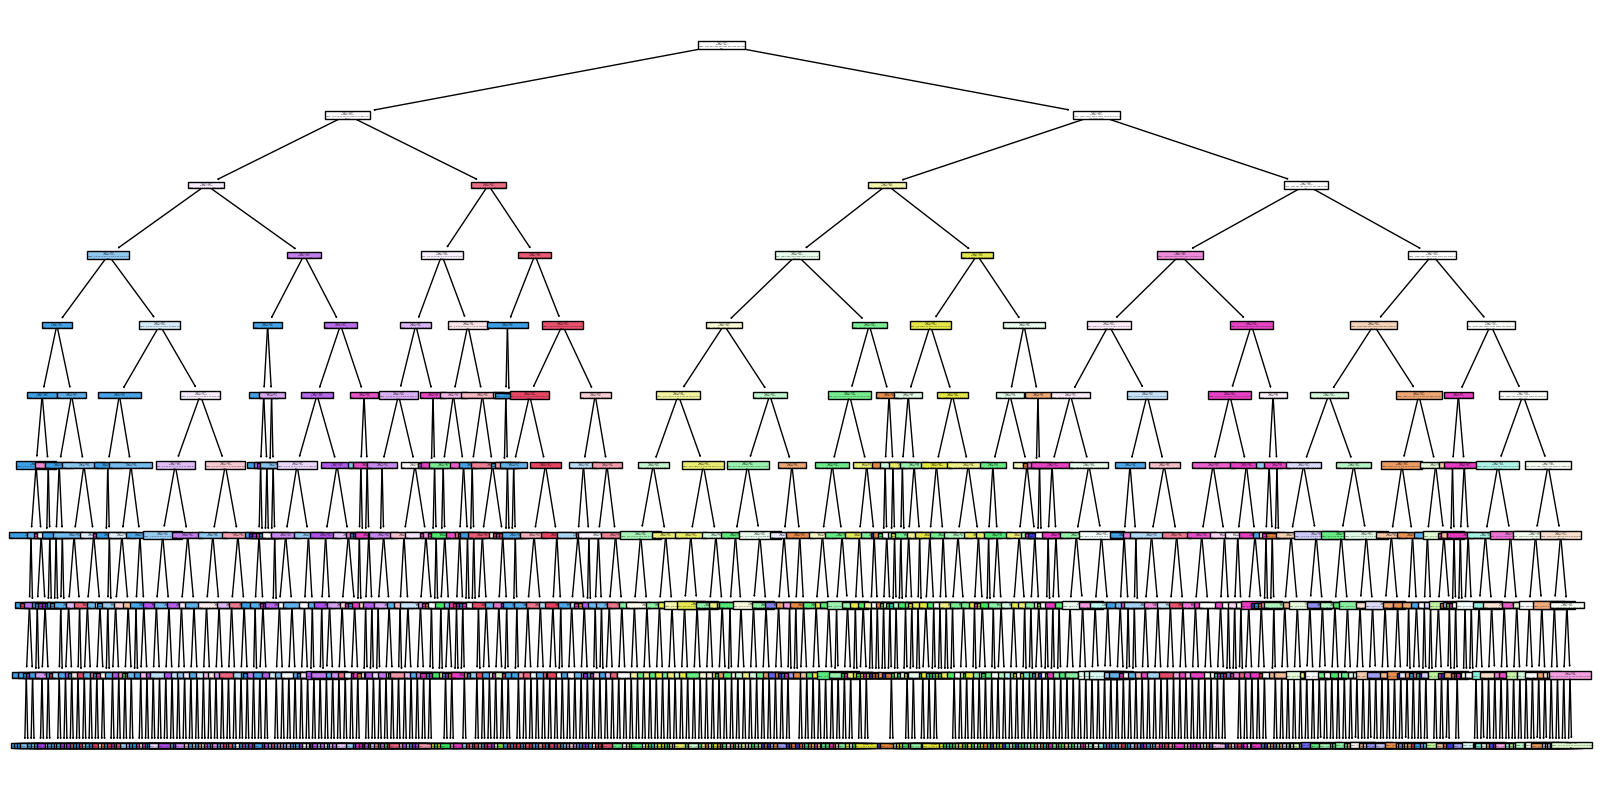

In [32]:
plt.figure(figsize=(20, 10))
tree.plot_tree(clf, filled=True)
plt.show()

In [10]:
accuracy4 = accuracy_score(y_test, y_pred4)
print(accuracy4)

0.7194


In [11]:
precision4 = precision_score(y_test,y_pred4,average=None)
print(precision4)

[0.74589266 0.89044039 0.46231884 0.70622568 0.57911392 0.87868481
 0.42791762 0.77767857 0.94929881 0.87362086]


#### Σχολιασμός επιδόσεων και συμπεριφοράς

Θα βασιστούμε και πάλι στα αποτελέσματα των accuracy και precision για τον σχολιασμό.\
Αρχικά παρατηρούμε πως το accuracy είναι σχετικά υψηλό, δηλαδή για κάθε 10 ρούχα, αναγνωρίζει με επιτυχία τα 7. Μπαίνοντας σε μεγαλύτερο βάθος και μελετώντας τα αποτελέσματα του precision βλέπουμε ότι διακρίνει με σχετικά υψηλή ακρίβεια τα ρούχα, ωστόσο δυσκολεύεται σε ορισμένες κατηγορίες όπου το precision πέφτει μέχρι και το 0.42.\
Παρακάτω ακολουθεί και ένα γράφημα που απεικονίζει το precision για κάθε κατηγορία ξεχωριστά.

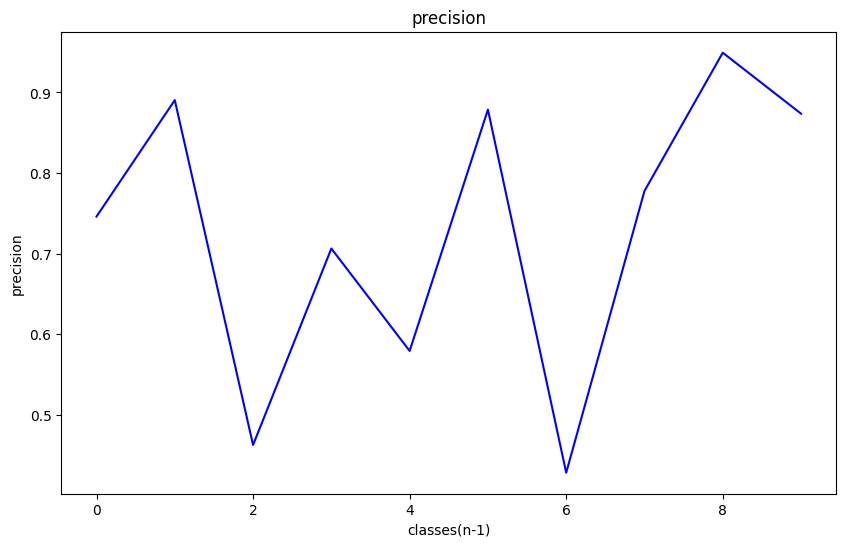

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(precision4,color='blue')
plt.title('precision')
plt.xlabel('classes(n-1)')
plt.ylabel('precision')
plt.show()

### RANDOM FOREST

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
random_forest= RandomForestClassifier(n_estimators = 100)
random_forest.fit(flattened_vectors_train, y_train)

RandomForestClassifier()

In [39]:
y_pred5 = random_forest.predict(flattened_vectors_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred5)
print("Accuracy:", accuracy)

Accuracy: 0.8251


In [41]:
precision5 = precision_score(y_test,y_pred5,average=None)
print("Precision:",precision5)

Precision: [0.7852349  0.94262295 0.70980392 0.80187793 0.70900474 0.92857143
 0.62132353 0.86761905 0.94824219 0.91391391]


#### Σχολιασμός επιδόσεων και συμπεριφοράς

Αυτή την φορά παρατηρούμε πως το accuracy είναι πολύ πιο υψηλό και έχει πολύ μεγαλύτερη ακρίβεια σε σχέση με το decision tree.\
Πολύ μεγάλο ενδιαφέρον έχουν και οι τιμές του precision, οι οποίες είναι όλες πολύ υψηλές πλέον, δείχνοντας την μεγάλη ακρίβεια που έχει στην αναγνώριση.\
Παρακάτω ακολουθεί πάλι και ένα γράφημα που απεικονίζει το precision για κάθε κατηγορία ξεχωριστά.

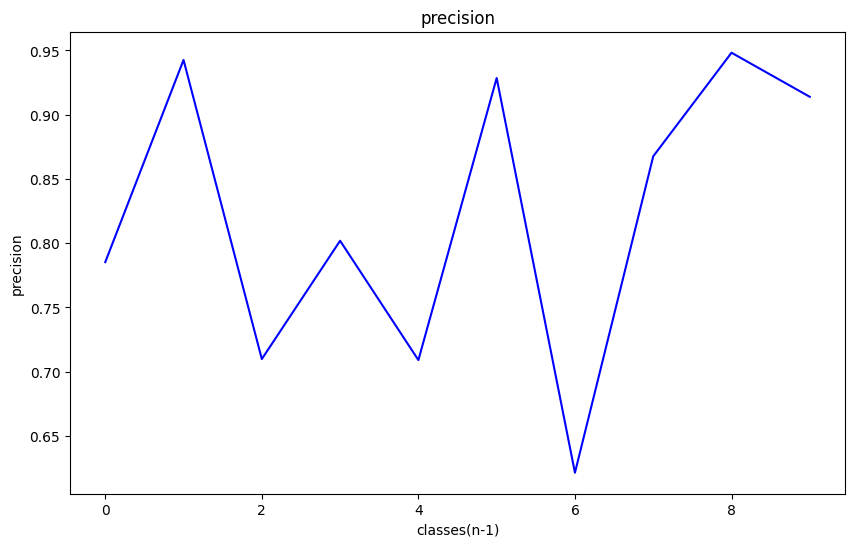

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(precision5,color='blue')
plt.title('precision')
plt.xlabel('classes(n-1)')
plt.ylabel('precision')
plt.show()

### SVM

#### 1) Linear SVM Classifier

#### 1.1 C = 1

In [46]:
# importing svm model
from sklearn import svm

In [47]:
#Create a svm Classifier
svm1 = svm.SVC(kernel='linear',C=1,max_iter=500)

In [48]:
# fitting the data
q =svm1.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [50]:
svm_pred1 =svm1.predict(flattened_vectors_test)

In [51]:
svm_accuracy = accuracy_score(y_test, svm_pred1)
print("Accuracy:", svm_accuracy)

Accuracy: 0.5265


In [52]:
svm_precision = precision_score(y_test,svm_pred1,average=None)
print("Precision:",svm_precision)

Precision: [0.54545455 0.58877928 0.45578231 0.21135029 0.39953811 0.86556604
 0.23460411 0.60629317 0.93028571 0.721875  ]


#### 1.2 C= 10

In [53]:
#Create a svm Classifier
svm2 = svm.SVC(kernel='linear',C=10,max_iter=500)

In [54]:
# fitting the data
svm2.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=10, kernel='linear', max_iter=500)

In [55]:
svm_pred2 =svm2.predict(flattened_vectors_test)

In [56]:
svm_accuracy2 = accuracy_score(y_test, svm_pred2)
print("Accuracy:", svm_accuracy2)

Accuracy: 0.3595


In [57]:
svm_precision2 = precision_score(y_test,svm_pred2,average=None)
print("Precision:",svm_precision2)

Precision: [0.18409426 0.40875912 0.14056225 0.43658537 0.40439932 0.50122549
 0.23231084 0.58553792 0.54511278 0.53348214]


#### 1.3 C = 100

In [58]:
#Create a svm Classifier
svm3 = svm.SVC(kernel='linear',C=100,max_iter=500)

In [59]:
# fitting the data
svm3.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=100, kernel='linear', max_iter=500)

In [60]:
svm_pred3 =svm3.predict(flattened_vectors_test)

In [61]:
svm_accuracy3 = accuracy_score(y_test, svm_pred3)
print("Accuracy:", svm_accuracy3)

Accuracy: 0.3937


In [62]:
svm_precision3 = precision_score(y_test,svm_pred3,average=None)
print("Precision:",svm_precision3)

Precision: [0.19642857 0.04875805 0.25306122 0.38021638 0.36132316 0.64310148
 0.21957672 0.64842454 0.51271754 0.7447619 ]


### Σχολιασμός επιδόσεων και συμπεριφοράς

Παρατηρούμε πως η ακρίβεια δεν είναι πλέον και πολύ υψηλή. Ενώ για C=1 το accuracy είναι οριακά πάνω από 0.5, στις άλλες δύο περιπτώσεις πέφτει σχεδόν στο 1/3.\
Πολύ χαμηλό είναι και το precision στις τρεις περιπτώσεις για όλες τις κατηγορίες.\
Παρακάτω ακολουθεί ξανά ένα γράφημα για την αναπαράσταση του precision.

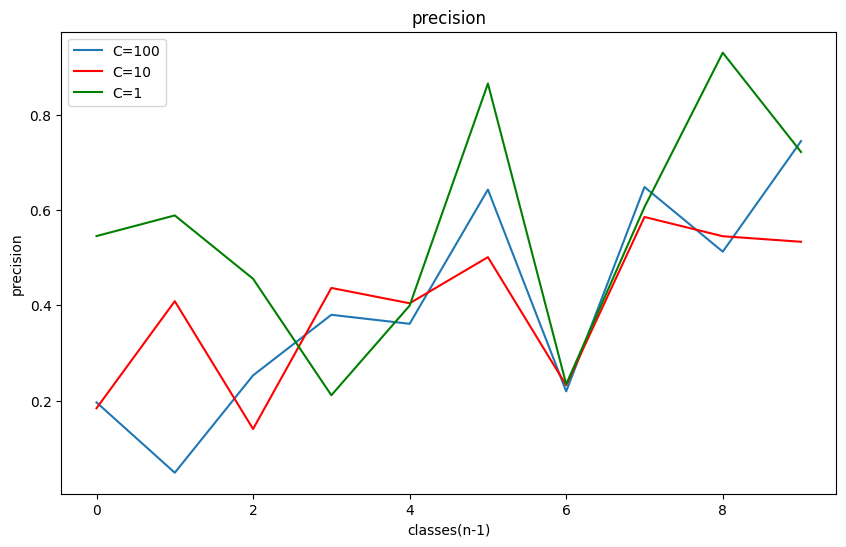

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(svm_precision3,label='C=100')
plt.plot(svm_precision2,color='red',label='C=10')
plt.plot(svm_precision,color='green',label='C=1')
plt.title('precision')
plt.xlabel('classes(n-1)')
plt.ylabel('precision')
plt.legend()
plt.show()

### 2) SVM RBF Kernel

#### 2.1 C = 1

 - gamma = 0.02

In [10]:
#Create a svm Classifier
svm4 = svm.SVC(kernel='rbf',C=1,max_iter=500,gamma=0.02)

In [11]:
# fitting the data
svm4.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=1, gamma=0.02, max_iter=500)

In [12]:
svm_pred4 =svm4.predict(flattened_vectors_test)

In [13]:
svm_accuracy4 = accuracy_score(y_test, svm_pred4)
print("Accuracy:", svm_accuracy4)

Accuracy: 0.4908


In [14]:
svm_precision4 = precision_score(y_test,svm_pred4,average=None)
print("Precision:",svm_precision4)

Precision: [0.76216216 0.69242199 0.28654971 0.44762757 0.38360324 0.58805745
 0.22230681 0.60576923 0.90319549 0.59480025]


 - gamma = 0.1

In [15]:
#Create a svm Classifier
svm5 = svm.SVC(kernel='rbf',C=1,max_iter=500,gamma=0.1)

In [16]:
# fitting the data
svm5.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=1, gamma=0.1, max_iter=500)

In [17]:
svm_pred5 =svm5.predict(flattened_vectors_test)

In [18]:
svm_accuracy5 = accuracy_score(y_test, svm_pred5)
print("Accuracy:", svm_accuracy5)

Accuracy: 0.5836


In [19]:
svm_precision5 = precision_score(y_test,svm_pred5,average=None)
print("Precision:",svm_precision5)

Precision: [0.75034294 0.67354196 0.39929329 0.56844548 0.34840426 0.8002594
 0.23111111 0.68055556 0.95064166 0.73632653]


 - gamma = 1

In [20]:
#Create a svm Classifier
svm6 = svm.SVC(kernel='rbf',C=1,max_iter=500,gamma=1)

In [21]:
# fitting the data
svm6.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=1, gamma=1, max_iter=500)

In [22]:
svm_pred6 =svm6.predict(flattened_vectors_test)

In [23]:
svm_accuracy6 = accuracy_score(y_test, svm_pred6)
print("Accuracy:", svm_accuracy6)

Accuracy: 0.7109


In [24]:
svm_precision6 = precision_score(y_test,svm_pred6,average=None)
print("Precision:",svm_precision6)

Precision: [0.65462754 0.91989664 0.44779453 0.6361465  0.67191601 0.7405892
 0.44789357 0.88812561 0.95441031 0.90494792]


#### Σχολιασμός επιδόσεων και συμπεριφοράς

Με βάση τόσο το accuracy όσο και το precision, μπορούμε πολύ εύκολα να διακρίνουμε πως για C=1 η καλύτερη περίπτωση είναι όταν θέτουμε το gamma=1,αφού σε αυτή την περίπτωση λαμβάνουμε τις υψηλότερες τιμές.

#### 2.2 C = 10

 - gamma = 0.02

In [25]:
#Create a svm Classifier
svm7 = svm.SVC(kernel='rbf',C=10,max_iter=500,gamma=0.02)

In [26]:
# fitting the data
svm7.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=10, gamma=0.02, max_iter=500)

In [27]:
svm_pred7 =svm7.predict(flattened_vectors_test)

In [28]:
svm_accuracy7 = accuracy_score(y_test, svm_pred7)
print("Accuracy:", svm_accuracy7)

Accuracy: 0.5157


In [29]:
svm_precision7 = precision_score(y_test,svm_pred7,average=None)
print("Precision:",svm_precision7)

Precision: [0.52009456 0.67091295 0.38118812 0.71052632 0.28571429 0.78389831
 0.21579805 0.75308642 0.95413759 0.5794155 ]


 - gamma = 0.1

In [30]:
#Create a svm Classifier
svm8 = svm.SVC(kernel='rbf',C=10,max_iter=500,gamma=0.1)

In [31]:
# fitting the data
svm8.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=10, gamma=0.1, max_iter=500)

In [32]:
svm_pred8 =svm8.predict(flattened_vectors_test)

In [33]:
svm_accuracy8 = accuracy_score(y_test, svm_pred8)
print("Accuracy:", svm_accuracy8)

Accuracy: 0.5639


In [34]:
svm_precision8 = precision_score(y_test,svm_pred8,average=None)
print("Precision:",svm_precision8)

Precision: [0.5728223  0.47577093 0.43853211 0.3578869  0.475      0.63613655
 0.28280702 0.73464658 0.9637827  0.81083953]


 - gamma = 1

In [35]:
#Create a svm Classifier
svm9 = svm.SVC(kernel='rbf',C=10,max_iter=500,gamma=1)

In [36]:
# fitting the data
svm9.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=10, gamma=1, max_iter=500)

In [37]:
svm_pred9 =svm9.predict(flattened_vectors_test)

In [38]:
svm_accuracy9 = accuracy_score(y_test, svm_pred9)
print("Accuracy:", svm_accuracy9)

Accuracy: 0.7138


In [39]:
svm_precision9 = precision_score(y_test,svm_pred9,average=None)
print("Precision:",svm_precision9)

Precision: [0.63578047 0.87656702 0.45994065 0.75982533 0.65076923 0.64227086
 0.55172414 0.9        0.95540139 0.87898089]


#### Σχολιασμός συμπεριφοράς και επιδόσεων

Με βάση τόσο το accuracy όσο και το precision, μπορούμε πολύ εύκολα να διακρίνουμε πως για C=10 η καλύτερη περίπτωση είναι όταν θέτουμε το gamma=1,αφού σε αυτή την περίπτωση λαμβάνουμε τις υψηλότερες τιμές.

#### 2.3 C = 100

 - gamma = 0.02

In [40]:
#Create a svm Classifier
svm10 = svm.SVC(kernel='rbf',C=100,max_iter=500,gamma=0.02)

In [41]:
# fitting the data
svm10.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=100, gamma=0.02, max_iter=500)

In [42]:
svm_pred10 =svm10.predict(flattened_vectors_test)

In [43]:
svm_accuracy10 = accuracy_score(y_test, svm_pred10)
print("Accuracy:", svm_accuracy10)

Accuracy: 0.4613


In [44]:
svm_precision10 = precision_score(y_test,svm_pred10,average=None)
print("Precision:",svm_precision10)

Precision: [0.33451327 0.76387582 0.4057187  0.61523438 0.42400881 0.33129833
 0.31111111 0.4961039  0.94555874 0.51685393]


 - gamma = 0.1

In [45]:
#Create a svm Classifier
svm11 = svm.SVC(kernel='rbf',C=100,max_iter=500,gamma=0.1)

In [46]:
# fitting the data
svm11.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=100, gamma=0.1, max_iter=500)

In [47]:
svm_pred11 =svm11.predict(flattened_vectors_test)

In [48]:
svm_accuracy11 = accuracy_score(y_test, svm_pred11)
print("Accuracy:", svm_accuracy11)

Accuracy: 0.5178


In [49]:
svm_precision11 = precision_score(y_test,svm_pred11,average=None)
print("Precision:",svm_precision11)

Precision: [0.51584022 0.49865952 0.35791481 0.35462555 0.54564756 0.49478207
 0.33145434 0.77070828 0.95642202 0.66423358]


 - gamma  = 1

In [50]:
#Create a svm Classifier
svm12 = svm.SVC(kernel='rbf',C=100,max_iter=500,gamma=1)

In [51]:
# fitting the data
svm12.fit(flattened_vectors_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=100, gamma=1, max_iter=500)

In [52]:
svm_pred12 =svm12.predict(flattened_vectors_test)

In [53]:
svm_accuracy12 = accuracy_score(y_test, svm_pred12)
print("Accuracy:", svm_accuracy12)

Accuracy: 0.6174


In [54]:
svm_precision12 = precision_score(y_test,svm_pred12,average=None)
print("Precision:",svm_precision12)

Precision: [0.56923077 0.68110236 0.36850783 0.4495114  0.64563107 0.60609994
 0.51648352 0.8879203  0.95544554 0.89071856]


#### Σχολιασμός επιδόσεων και συμπεριφοράς

Με βάση τόσο το accuracy όσο και το precision, μπορούμε πολύ εύκολα να διακρίνουμε πως για C=100 η καλύτερη περίπτωση είναι και πάλι όταν θέτουμε το gamma=1,αφού σε αυτή την περίπτωση λαμβάνουμε τις υψηλότερες τιμές.

### Σχολιασμός επιδόσεων και συμπεριφοράς(SVM RBF Kernel)

Σε αυτή την περίπτωση παρατηρούμε πως η επίδοση έχει πλέον βελτιωθεί. Συγκριτικά με το γραμμικό μοντέλο, παρατηρούμε πως είναι πολύ πιο υψηλό, τόσο το accuracy όσο και η τιμές του precision.\
Παρακάτω ακολουθεί ξανά ένα γράφημα που αναπαριστά το precision, μόνο για τις υψηλότερες τιμές για κάθε C.

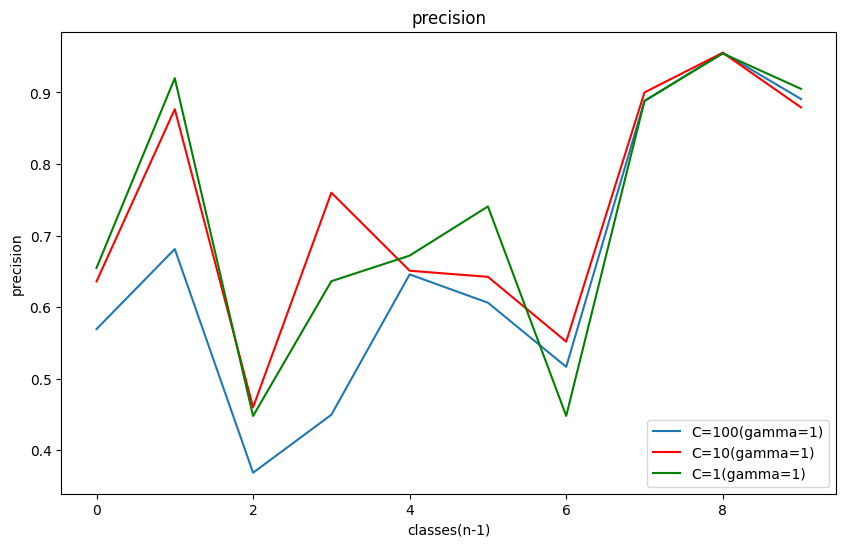

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(svm_precision12,label='C=100(gamma=1)')
plt.plot(svm_precision9,color='red',label='C=10(gamma=1)')
plt.plot(svm_precision6,color='green',label='C=1(gamma=1)')
plt.title('precision')
plt.xlabel('classes(n-1)')
plt.ylabel('precision')
plt.legend()
plt.show()

### Feed Forward Neural Network

In [53]:
from sklearn.neural_network import MLPClassifier
#import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,Input,LeakyReLU

#### Υλοποίηση του νευρωνικού δικτύου

Αρχικά ορίζουμε input το οποίο θα είναι 49. Έπειτα προχωράμε στα κρυμμένα επίπεδα. Όπου το πρώτο(hidden1) θα έχει 100 units,το δεύτερο(hidden2) επίσης 100 ενώ το τρίτο(hidden3) θα έχει 50. Και στα τρία επίπεδα ορίζουμε ως activation function την Leaky ReLu.\
Τέλος ορίζουμε το επίπεδο εξόδου με 10 νευρώνες,όσες δηλαδή και το πλήθος των κατηγοριών μας.\
Φυσικά κάθε επίπεδο το συνδέουμε με το προηγούμενό του.

In [54]:
# starting with the input layer
input_layer = Input(shape=(flattened_vectors_train.shape[1],))

# continuing with the 3 hidden layers

# defining the activation function
leaky_relu = tf.keras.layers.LeakyReLU()

# hidden layer 1 ,activation='leaky_relu'
hidden1 = Dense(units=100,activation=leaky_relu)(input_layer)

# hidden layer 2
hidden2 = Dense(units=100,activation=leaky_relu)(hidden1)

# hidden layer 3
hidden3 = Dense(units=50,activation=leaky_relu)(hidden2)

# output layer
output_layer = Dense(10,activation='softmax')(hidden3)



In [55]:
# creating the model
nn_model =  Model(inputs=input_layer,outputs=output_layer)

In [56]:
# compiling the model
nn_model.compile(optimizer=tf.keras.optimizers.Adam(),loss= 'mean_squared_error',metrics=['accuracy'])


In [57]:
nn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 49)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │           5,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,660 (80.70 KB)

 Trainable params: 20,660 (80.70 KB)

 Non-trainable params: 0 (0.00 B)

Με την μέθοδο .summary(), βλέπουμε πως το πλήθος των παραμέτρων του συγκεκριμένου δικτύου είναι 20.660(!).

In [58]:
y_train_one_hot1 = tf.one_hot(y_train, depth=10)
y_test_one_hot1 = tf.one_hot(y_test, depth=10)

In [59]:
# performing fitting
training_results = nn_model.fit(flattened_vectors_train,y_train_one_hot1,validation_data=(flattened_vectors_test,y_test_one_hot1),epochs=100,batch_size = 50)

Epoch 1/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6456 - loss: 0.0468 - val_accuracy: 0.7456 - val_loss: 0.0348
Epoch 2/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7573 - loss: 0.0336 - val_accuracy: 0.7805 - val_loss: 0.0312
Epoch 3/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7700 - loss: 0.0318 - val_accuracy: 0.7669 - val_loss: 0.0328
Epoch 4/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7796 - loss: 0.0310 - val_accuracy: 0.7845 - val_loss: 0.0300
Epoch 5/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7865 - loss: 0.0298 - val_accuracy: 0.7902 - val_loss: 0.0294
Epoch 6/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7885 - loss: 0.0295 - val_accuracy: 0.7937 - val_loss: 0.0289
Epoch 7/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7936 - loss: 0.0290 - val_accuracy: 0.7986 - val_loss: 0.0282
Epoch 8/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7993 - loss: 0

#### PLOTS

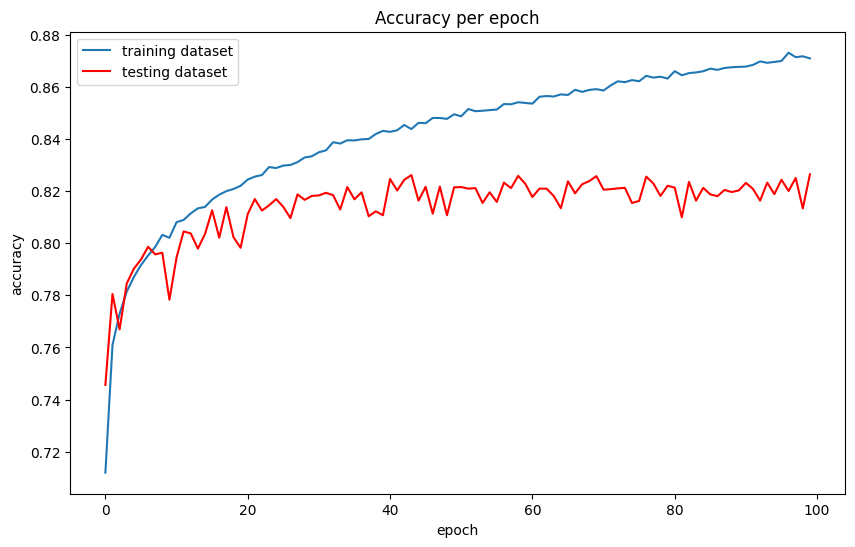

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(training_results.history['accuracy'],label='training dataset')
plt.plot(training_results.history['val_accuracy'],color='red',label='testing dataset')
plt.title('Accuracy per epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

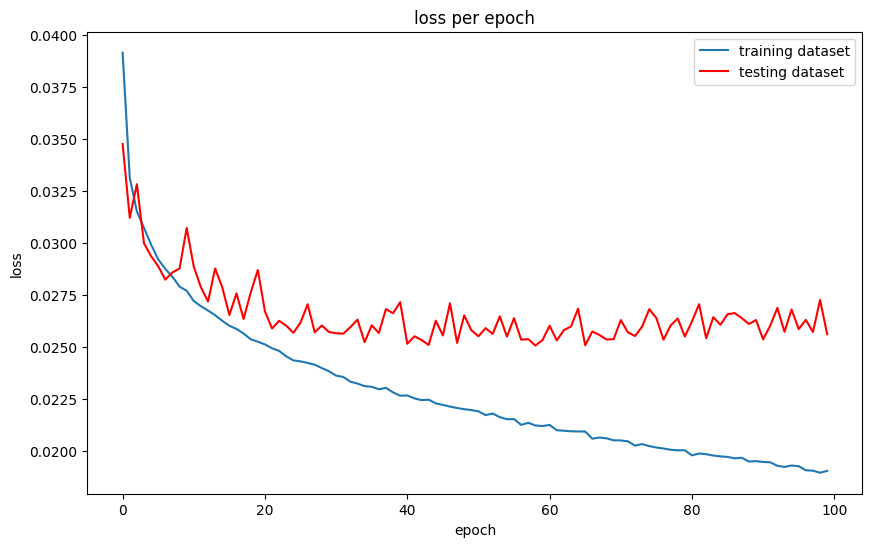

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(training_results.history['loss'],label='training dataset')
plt.plot(training_results.history['val_loss'],color='red',label='testing dataset')
plt.title('loss per epoch')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

#### Σχολιασμός επιδόσεων και συμπεριφοράς

Καθώς πραγματοποιούμε την εκπαίδευση του μοντέλου μας, παρατηρούμε πως το accuracy, τόσο στο train dataset όσο και στο test dataset, καθώς ο αριθμός της εποχής(epoch) στην οποία βρισκόμαστε αυξάνεται, αυξάνεται λογαριθμικά με το test dataset να έχει χαμηλότερο ρυθμό. Από την άλλη, παρατηρούμε πως το loss στο training dataset συνεχώς μειώνεται, ενώ  στο test dataset αρχικά μειώνεται μέχρι περίπου την εικοστή εποχή και μετά αρχίζει να σταθεροποιείται γύρω στο 0.0275.

## [Β] δεδομένα με την μορφή εικόνας

### CNN

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout

#### Υλοποίηση του νευρωνικού δικτύου

Παρακάτω υλοποιούμε το ζητούμενο δίκτυο, χρησιμοποιώντας την βιβλιοθήκη keras. Έχει αρκετά οφέλη η χρήση της, όπως την ταχύτητα του δικτύου.\
Αρχικά ορίζουμε την είσοδο μας η οποία είναι (1,28,28), όσο και οι εικόνες μας. Έπειτα ορίζουμε το πρώτο συνελικτικό επίπεδο(conv1) με 64 νευρώνες και το συνδέουμε με το input.\
Έπειτα έχουμε το δεύτερο συνελικτικό επίπεδο(conv2) με 128 νευρώνες και το συνδέουμε με το conv1. Αμέσως μετά, υλοποιούμε το max-pooling με παράθυρο 2x2 και ορίζουμε το τρίτο συνελικτικό επίπεδο(conv3) με 256 νευρώνες.\
Κάνουμε flatten τα δεδομένα και τα περνάμε από το πρώτο fully-connected layer(cnn_fc1) το οποίο έχει 100 νευρώνες.\
Κάνουμε drop με συντελεστή 0.3 και τέλος υλοποιούμε την έξοδό μας με 10 νευρώνες.

In [97]:
# defining our cnn model


cnn_input= Input(shape=(1,28,28))
conv1= Conv2D(64,kernel_size=3,padding = 'same')(cnn_input)
conv2= Conv2D(128,kernel_size=3,padding = 'same')(conv1)
pool= MaxPooling2D(2,padding = 'same')(conv2)
conv3= Conv2D(256,kernel_size=3,padding = 'same')(pool)
flatten = Flatten()(conv3)
cnn_fc1= Dense(100)(flatten)
cnn_drop= Dropout(0.3)(cnn_fc1)
cnn_output= Dense(10,activation='softmax')(cnn_drop)

In [98]:
cnn_model= Model(inputs=cnn_input,outputs=cnn_output)

In [99]:
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(),loss= 'categorical_crossentropy',metrics=['accuracy'])

In [100]:
cnn_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 1, 28, 28)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 1, 28, 64)           │          16,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 1, 28, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 14, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 1, 14, 256)          │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 3584)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 100)                 │         358,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 744,726 (2.84 MB)

 Trainable params: 744,726 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

Στο συγκεκριμένο σημείο φτιάχνουμε κατάλληλα τα δεδομένα μας και όσον αφορά τις κατηγορίες μας, τις περνάμε από το  one_hot encoding.

In [6]:
images_train2 = torch.tensor(data_scaled_train).view(-1, 1, 28, 28)
images_test2 = torch.tensor(data_scaled_test).view(-1, 1, 28, 28)
images_train2=images_train2.double()
images_test2= images_test2.double()

In [7]:
y_train_one_hot2 = tf.one_hot(y_train, depth=10)
y_test_one_hot2 = tf.one_hot(y_test, depth=10)

Παρακάτω υλοποιούμε το fitting του μοντέλου. Ως validation data χρησιμοποιούμε το test dataset έτσι ώστε να εξάγουμε το accuracy και το loss και να φτιάξουμε τις γραφικές παραστάσεις που μας ζητούνται

In [101]:
# performing fitting
cnn_results = cnn_model.fit(images_train2,y_train_one_hot2,validation_data=(images_test2,y_test_one_hot2),epochs=100,batch_size = 50)

Epoch 1/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.7617 - loss: 0.6818 - val_accuracy: 0.8367 - val_loss: 0.4778
Epoch 2/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.8420 - loss: 0.4530 - val_accuracy: 0.8484 - val_loss: 0.4382
Epoch 3/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.8508 - loss: 0.4207 - val_accuracy: 0.8588 - val_loss: 0.4026
Epoch 4/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8596 - loss: 0.3960 - val_accuracy: 0.8629 - val_loss: 0.3947
Epoch 5/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.8723 - loss: 0.3654 - val_accuracy: 0.8595 - val_loss: 0.4112
Epoch 6/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.8747 - loss: 0.3551 - val_accuracy: 0.8704 - val_loss: 0.3898
Epoch 7/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.8798 - loss: 0.3393 - val_accuracy: 0.8634 - val_loss: 0.3989
Epoch 8/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 

#### PLOTS FOR THE FIRST CASE

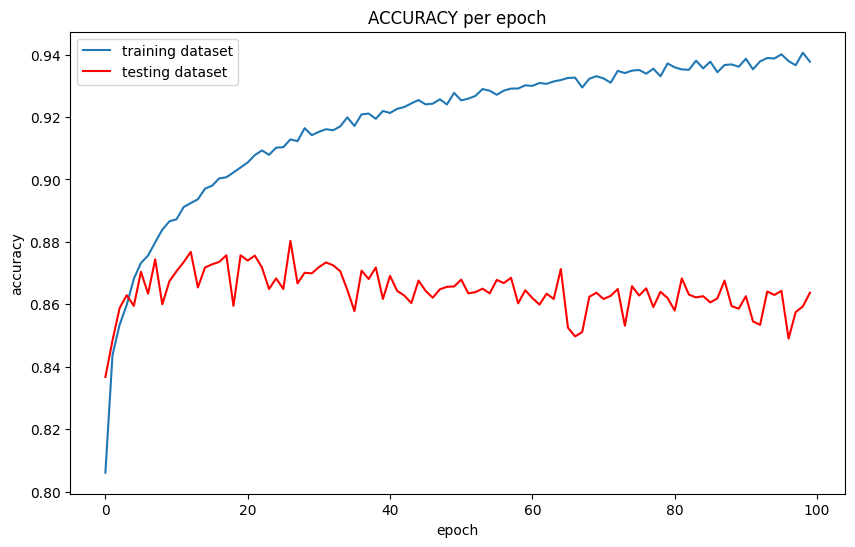

In [102]:
plt.figure(figsize=(10, 6))
plt.plot(cnn_results.history['accuracy'],label='training dataset')
plt.plot(cnn_results.history['val_accuracy'],color='red',label='testing dataset')
plt.title('ACCURACY per epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

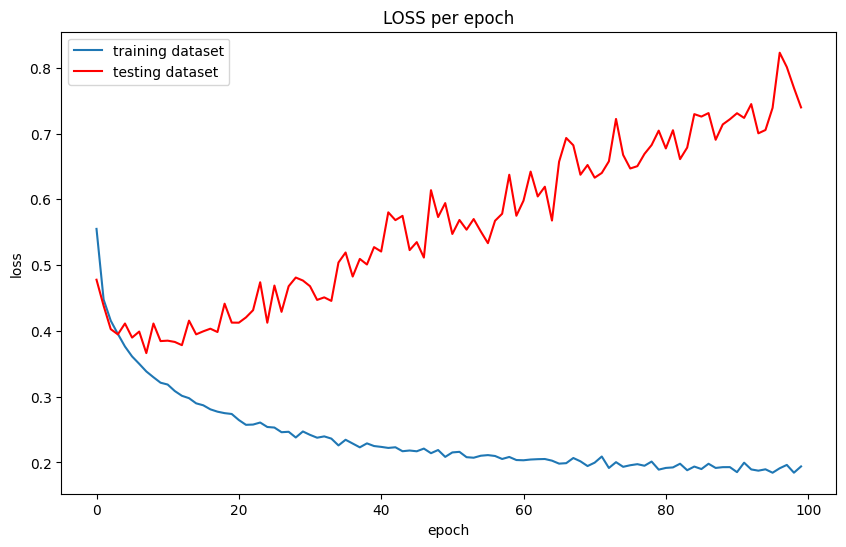

In [103]:
plt.figure(figsize=(10, 6))
plt.plot(cnn_results.history['loss'],label='training dataset')
plt.plot(cnn_results.history['val_loss'],color='red',label='testing dataset')
plt.title('LOSS per epoch')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### second CNN

In [8]:
# creating our model

cnn_input2= Input(shape=(1,28,28))
conv12= Conv2D(32,kernel_size=3,padding = 'same')(cnn_input2)
conv22= Conv2D(64,kernel_size=3,padding = 'same')(conv12)
pool2= MaxPooling2D(2,padding = 'same')(conv22)
conv32= Conv2D(128,kernel_size=3,padding = 'same')(pool2)
flatten2 = Flatten()(conv32)
cnn_fc12= Dense(100)(flatten2)
cnn_drop2= Dropout(0.3)(cnn_fc12)
cnn_output2= Dense(10,activation='softmax')(cnn_drop2)

In [9]:
cnn_model2= Model(inputs=cnn_input2,outputs=cnn_output2)

In [10]:
cnn_model2.compile(optimizer=tf.keras.optimizers.Adam(),loss= 'categorical_crossentropy',metrics=['accuracy'])

In [11]:
cnn_results2 = cnn_model2.fit(images_train2,y_train_one_hot2,validation_data=(images_test2,y_test_one_hot2),epochs=100,batch_size = 50)

Epoch 1/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7548 - loss: 0.6959 - val_accuracy: 0.8381 - val_loss: 0.4570
Epoch 2/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8371 - loss: 0.4638 - val_accuracy: 0.8352 - val_loss: 0.4573
Epoch 3/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8529 - loss: 0.4180 - val_accuracy: 0.8571 - val_loss: 0.4033
Epoch 4/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8608 - loss: 0.3944 - val_accuracy: 0.8660 - val_loss: 0.3861
Epoch 5/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8667 - loss: 0.3747 - val_accuracy: 0.8730 - val_loss: 0.3713
Epoch 6/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8700 - loss: 0.3647 - val_accuracy: 0.8708 - val_loss: 0.3777
Epoch 7/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8759 - loss: 0.3508 - val_accuracy: 0.8737 - val_loss: 0.3633
Epoch 8/100
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8776

#### PLOTS FOR THE SECOND CASE

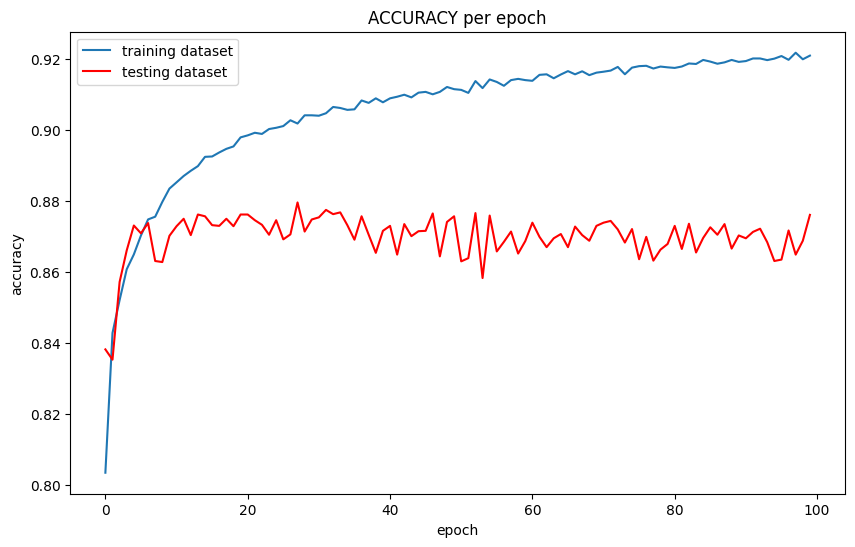

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(cnn_results2.history['accuracy'],label='training dataset')
plt.plot(cnn_results2.history['val_accuracy'],color='red',label='testing dataset')
plt.title('ACCURACY per epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

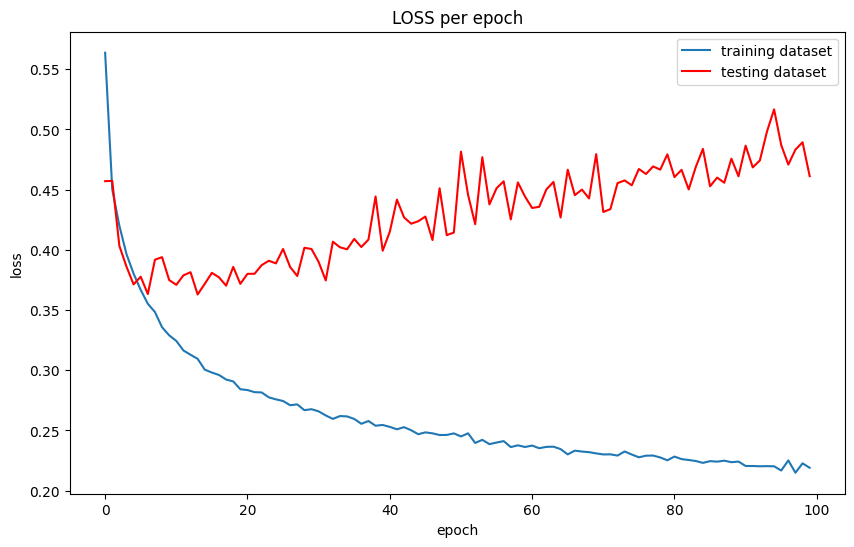

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(cnn_results2.history['loss'],label='training dataset')
plt.plot(cnn_results2.history['val_loss'],color='red',label='testing dataset')
plt.title('LOSS per epoch')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### Σχολιασμός διαφορετικών πλήθους φίλτρων στο testing dataset

Πολύ ενδιαφέρον παρουσιάζει η επίδραση που έχει η τοποθέτηση διαφορετικών φίλτρων στο μοντέλο που δημιουργήσαμε. Στην πρώτη περίπτωση, όπου το πλήθος των φίλτρων σε κάθε επίπεδο είναι μεγαλύτερο, το loss σε κάθε epoch αυξάνεται με γραμμικό, περίπου, ρυθμό.\
Στην δεύτερη περίπτωση, με λιγότερα φίλτρα σε κάθε επίπεδο, ενώ το accuracy παραμένει περίπου το ίδιο με την πρώτη περίπτωση, το loss δεν ακολουθεί αυτή την γραμμική αύξηση. Αντιθέτως, ενώ στα πρώτα epoch μειώνεται, μετά παρουσιάζει μία αύξηση και τελικά φτάνει σε loss με τιμή περίπου 0.45, το οποίο είναι πολύ χαμηλότερο από αυτό στην πρώτη περίπτωση.